# Análise Preditiva e Prescritiva em Epidemiologia

| Tipo de análise | Pergunta central |
|---|---|
| Descritiva | O que aconteceu? |
| Diagnóstica | Por que aconteceu? |
| Preditiva | O que provavelmente vai acontecer? |
| Prescritiva | O que devemos fazer? |



## 1. Instalação de dependências
```bash
pip install scikit-learn
```

## 2. Importação das bibliotecas

Vamos utilizar `pandas`, `numpy`, `matplotlib` e `scikit-learn`.


In [8]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


## 3. Carregamento da base

Usaremos a base fake de epidemiologia criada na aula anterior.


In [10]:
df = pd.read_csv("dataset_epidemiologia_fake.csv")
df.head()


,Paciente_ID,Idade,Sexo,Regiao,Mes_Diagnostico,Tabagismo,Exposicao,Atividade_Fisica,Vacinado,Comorbidade,IMC,Dias_Sintomas,Marcador_Inflamatorio,Internacao,Desfecho_Grave
0,1,38,Masculino,Norte,Abr,Não,Não exposto,Baixa,Não,Sim,36.40,6,4.16,Não,Não
1,2,21,Feminino,Sul,Jun,Não,Não exposto,Alta,Sim,Não,26.70,8,4.59,Não,Não
2,3,52,Masculino,Norte,Abr,Não,Não exposto,Alta,Sim,Não,27.80,4,4.05,Não,Não
3,4,46,Feminino,Sul,Abr,Não,Não exposto,Baixa,Não,Sim,27.90,5,3.95,Não,Não
4,5,72,Feminino,Leste,Mai,Não,Não exposto,Moderada,Sim,Não,23.00,4,3.29,Não,Não


## 4. Revisão rápida da estrutura

Antes de modelar, sempre revisamos tamanho da base, tipos das variáveis, valores ausentes e variável-alvo.


In [11]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")


Linhas: 600
Colunas: 15


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Paciente_ID            600 non-null    int64  
 1   Idade                  600 non-null    int64  
 2   Sexo                   600 non-null    str    
 3   Regiao                 600 non-null    str    
 4   Mes_Diagnostico        600 non-null    str    
 5   Tabagismo              600 non-null    str    
 6   Exposicao              600 non-null    str    
 7   Atividade_Fisica       600 non-null    str    
 8   Vacinado               600 non-null    str    
 9   Comorbidade            600 non-null    str    
 10  IMC                    582 non-null    float64
 11  Dias_Sintomas          600 non-null    int64  
 12  Marcador_Inflamatorio  600 non-null    float64
 13  Internacao             600 non-null    str    
 14  Desfecho_Grave         600 non-null    str    
dtypes: float64(2), in

In [13]:
df.isnull().sum()

Paciente_ID               0
Idade                     0
Sexo                      0
Regiao                    0
Mes_Diagnostico           0
Tabagismo                 0
Exposicao                 0
Atividade_Fisica          0
Vacinado                  0
Comorbidade               0
IMC                      18
Dias_Sintomas             0
Marcador_Inflamatorio     0
Internacao                0
Desfecho_Grave            0
dtype: int64

# PARTE 1 — ANÁLISE PREDITIVA

## Pergunta central

> **Com base no perfil do paciente, conseguimos prever se ele será internado?**

Para esta aula, vamos criar um modelo de classificação.

- Variável-alvo: `Internacao`
- Classe positiva: `Sim`
- Classe negativa: `Não`

A ideia é prever uma categoria: **internou ou não internou**.


## 5. Seleção das variáveis

Variáveis explicativas usadas:

- Idade;
- Sexo;
- Região;
- Exposição;
- Atividade física;
- Vacinação;
- Comorbidade;
- IMC;
- Dias de sintomas;
- Marcador inflamatório.


In [14]:
features = [
    "Idade",
    "Sexo",
    "Regiao",
    "Exposicao",
    "Atividade_Fisica",
    "Vacinado",
    "Comorbidade",
    "IMC",
    "Dias_Sintomas",
    "Marcador_Inflamatorio"
]

target = "Internacao"

X = df[features]
y = df[target]

X.head()


,Idade,Sexo,Regiao,Exposicao,Atividade_Fisica,Vacinado,Comorbidade,IMC,Dias_Sintomas,Marcador_Inflamatorio
0,38,Masculino,Norte,Não exposto,Baixa,Não,Sim,36.40,6,4.16
1,21,Feminino,Sul,Não exposto,Alta,Sim,Não,26.70,8,4.59
2,52,Masculino,Norte,Não exposto,Alta,Sim,Não,27.80,4,4.05
3,46,Feminino,Sul,Não exposto,Baixa,Não,Sim,27.90,5,3.95
4,72,Feminino,Leste,Não exposto,Moderada,Sim,Não,23.00,4,3.29


In [15]:
y.value_counts()

Internacao
Não    551
Sim     49
Name: count, dtype: int64

## 6. Separação entre treino e teste

- **Treino:** usado para ensinar o modelo;
- **Teste:** usado para verificar como o modelo se comporta em dados que ele ainda não viu.

test_size=0.30, o Python pegou suas 600 linhas e as fatiou matematicamente:
70% para Treino: 600 * 0,70 = 420 linhas. O modelo usará esses casos para aprender os padrões dos pacientes.
30% para Teste: 600 * 0,30 = 180 linhas. Estes dados serão guardados em um "cofre" para testar o modelo depois.

O resultado indica 10 colunas. Embora a base original tinha 15 colunas, o objeto X que passamos para a função continha apenas 10 variáveis preditoras 

Idade	Sexo	Regiao	Exposicao	Atividade_Fisica	Vacinado	Comorbidade	IMC	Dias_Sintomas	Marcador_Inflamatorio

stratify=y = a proporção de pacientes internados foi mantida, 8,16% (49 / 600).

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (420, 10)
Teste: (180, 10)


## 7. Preparação dos dados para o modelo

Modelos de machine learning precisam receber dados em formato numérico.

- Variáveis numéricas serão preenchidas com a mediana.
- Variáveis categóricas serão transformadas com One-Hot Encoding.

One-Hot Encoding é uma técnica de tradução. Como modelos matemáticos não entendem palavras (como "Sim", "Não", "Suspeito"), precisamos converter essas categorias em números
le transforma cada categoria única de uma coluna em uma nova coluna individual, preenchendo-as com 0 ou 1.


In [17]:
numeric_features = [
    "Idade",
    "IMC",
    "Dias_Sintomas",
    "Marcador_Inflamatorio"
]

categorical_features = [
    "Sexo",
    "Regiao",
    "Exposicao",
    "Atividade_Fisica",
    "Vacinado",
    "Comorbidade"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 8. Modelo preditivo: Árvore de Decisão

Usaremos uma **Árvore de Decisão**, pois ela é visual, interpretável e adequada para uma primeira aula prática sobre classificação.


In [18]:
modelo = Pipeline(steps=[
    ("preprocessamento", preprocessor),
    ("classificador", DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ))
])

modelo.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## 9. Geração das previsões

Agora o modelo vai prever a internação nos dados de teste.


In [19]:
y_pred = modelo.predict(X_test)

resultado_previsoes = pd.DataFrame({
    "Real": y_test.values,
    "Previsto": y_pred
})

resultado_previsoes.head(10)


,Real,Previsto
0,Não,Sim
1,Não,Não
2,Não,Não
3,Não,Não
4,Não,Não
5,Não,Não
6,Não,Não
7,Não,Não
8,Não,Não
9,Não,Não


## 10. Avaliação simples do modelo

Acurácia responde:

> Em quantos casos o modelo acertou?


In [20]:
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia:.2f}")


Acurácia: 0.91


### Interpretação

A acurácia é útil, mas não deve ser a única métrica. Em problemas de saúde, errar um paciente de alto risco pode ser mais grave do que errar um paciente de baixo risco.


## 11. Matriz de confusão

A matriz de confusão mostra que tipos de acerto e erro o modelo cometeu.


In [21]:
matriz = confusion_matrix(y_test, y_pred, labels=["Não", "Sim"])

matriz_confusao = pd.DataFrame(
    matriz,
    index=["Real: Não", "Real: Sim"],
    columns=["Previsto: Não", "Previsto: Sim"]
)

matriz_confusao


,Previsto: Não,Previsto: Sim
Real: Não,157,8
Real: Sim,9,6


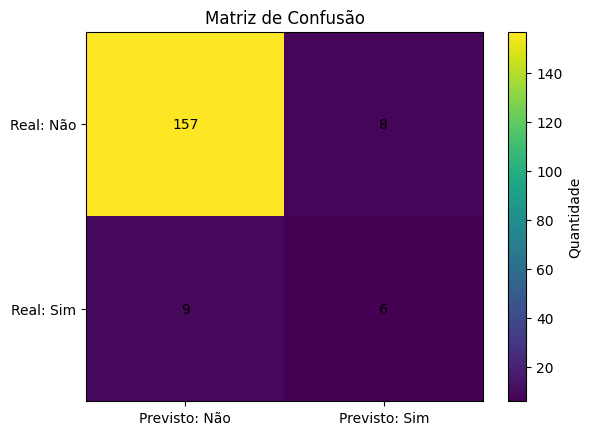

In [22]:
plt.imshow(matriz, aspect="auto")
plt.title("Matriz de Confusão")
plt.colorbar(label="Quantidade")

plt.xticks([0, 1], ["Previsto: Não", "Previsto: Sim"])
plt.yticks([0, 1], ["Real: Não", "Real: Sim"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, matriz[i, j], ha="center", va="center")

plt.show()


## 12. Relatório de classificação

Mostra precisão, recall e F1-score.


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Não       0.95      0.95      0.95       165
         Sim       0.43      0.40      0.41        15

    accuracy                           0.91       180
   macro avg       0.69      0.68      0.68       180
weighted avg       0.90      0.91      0.90       180



## 13. Importância das variáveis

A árvore de decisão permite verificar quais variáveis mais contribuíram para as decisões do modelo.


In [24]:
onehot = modelo.named_steps["preprocessamento"].named_transformers_["cat"].named_steps["onehot"]
nomes_categoricas = onehot.get_feature_names_out(categorical_features)

nomes_features = list(numeric_features) + list(nomes_categoricas)

importancias = modelo.named_steps["classificador"].feature_importances_

df_importancias = pd.DataFrame({
    "Variavel": nomes_features,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

df_importancias.head(15)


,Variavel,Importancia
2,Dias_Sintomas,0.48
3,Marcador_Inflamatorio,0.24
4,Sexo_Feminino,0.11
14,Atividade_Fisica_Baixa,0.06
17,Vacinado_Sim,0.05
0,Idade,0.04
19,Comorbidade_Sim,0.03
10,Regiao_Sul,0.00
7,Regiao_Leste,0.00
8,Regiao_Norte,0.00


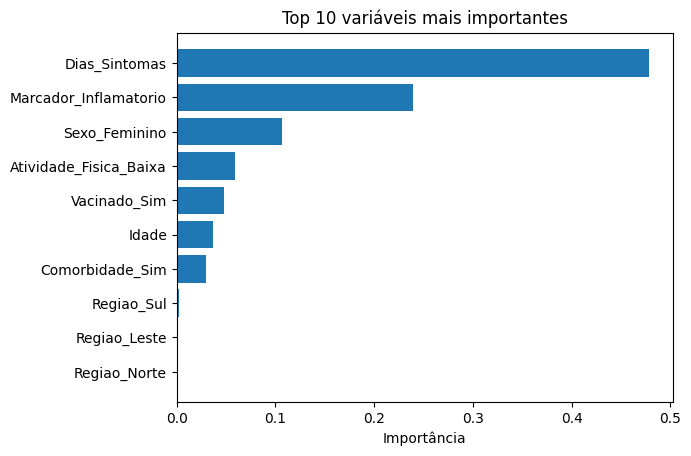

In [25]:
top_importancias = df_importancias.head(10)

plt.barh(top_importancias["Variavel"], top_importancias["Importancia"])
plt.title("Top 10 variáveis mais importantes")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.show()


### Interpretação

A importância das variáveis mostra quais fatores o modelo mais utilizou para separar pacientes com maior ou menor chance de internação.

Importância no modelo não significa causalidade absoluta.


## 14. Visualização simplificada da árvore

Limitamos a profundidade para fins didáticos.


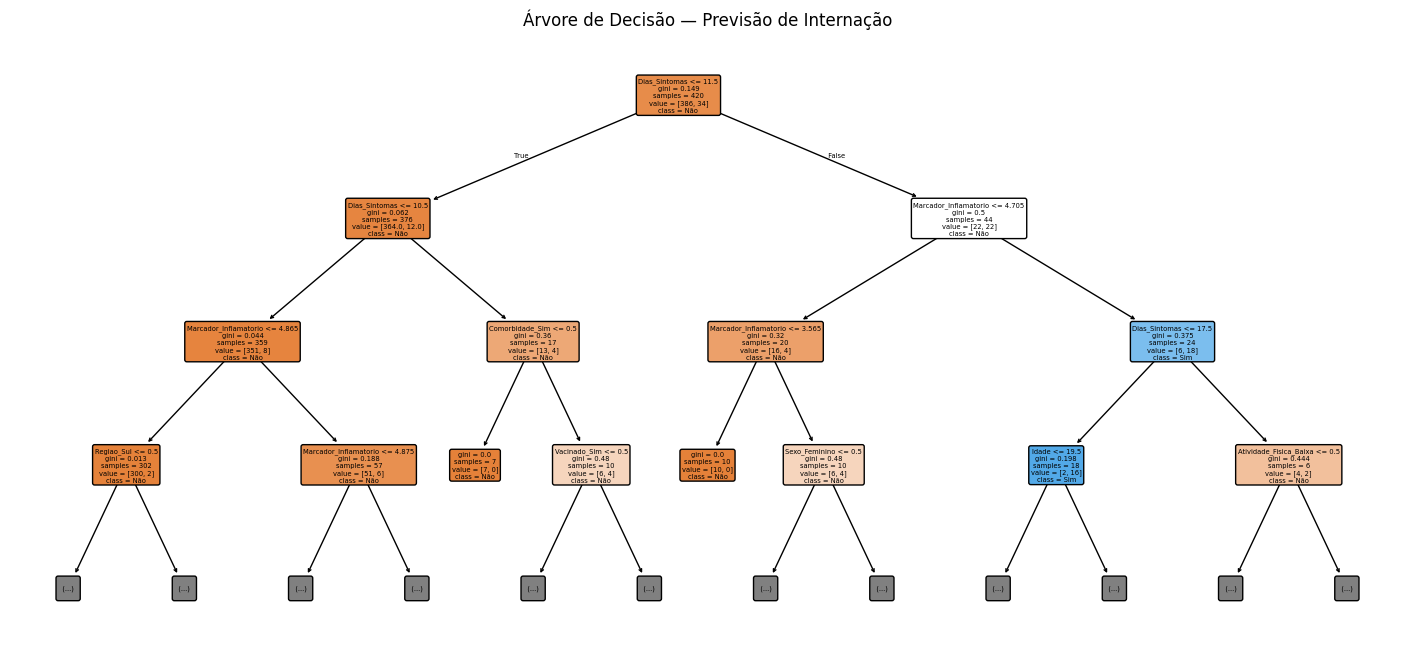

In [26]:
plt.figure(figsize=(18, 8))

plot_tree(
    modelo.named_steps["classificador"],
    feature_names=nomes_features,
    class_names=modelo.named_steps["classificador"].classes_,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Árvore de Decisão — Previsão de Internação")
plt.show()


## 15. Previsão para novos pacientes

Vamos simular novos pacientes fictícios e pedir para o modelo prever o risco de internação.


In [27]:
novos_pacientes = pd.DataFrame([
    {
        "Idade": 72,
        "Sexo": "Masculino",
        "Regiao": "Leste",
        "Exposicao": "Exposto",
        "Atividade_Fisica": "Baixa",
        "Vacinado": "Não",
        "Comorbidade": "Sim",
        "IMC": 32.0,
        "Dias_Sintomas": 14,
        "Marcador_Inflamatorio": 7.8
    },
    {
        "Idade": 28,
        "Sexo": "Feminino",
        "Regiao": "Sul",
        "Exposicao": "Não exposto",
        "Atividade_Fisica": "Alta",
        "Vacinado": "Sim",
        "Comorbidade": "Não",
        "IMC": 23.5,
        "Dias_Sintomas": 3,
        "Marcador_Inflamatorio": 2.1
    },
    {
        "Idade": 55,
        "Sexo": "Feminino",
        "Regiao": "Centro",
        "Exposicao": "Não exposto",
        "Atividade_Fisica": "Moderada",
        "Vacinado": "Sim",
        "Comorbidade": "Sim",
        "IMC": 28.4,
        "Dias_Sintomas": 8,
        "Marcador_Inflamatorio": 4.9
    }
])

novos_pacientes


,Idade,Sexo,Regiao,Exposicao,Atividade_Fisica,Vacinado,Comorbidade,IMC,Dias_Sintomas,Marcador_Inflamatorio
0,72,Masculino,Leste,Exposto,Baixa,Não,Sim,32.00,14,7.80
1,28,Feminino,Sul,Não exposto,Alta,Sim,Não,23.50,3,2.10
2,55,Feminino,Centro,Não exposto,Moderada,Sim,Sim,28.40,8,4.90


In [28]:
previsao = modelo.predict(novos_pacientes)
probabilidades = modelo.predict_proba(novos_pacientes)

classes = list(modelo.named_steps["classificador"].classes_)
indice_nao = classes.index("Não")
indice_sim = classes.index("Sim")

resultado_novos = novos_pacientes.copy()
resultado_novos["Previsao_Internacao"] = previsao
resultado_novos["Probabilidade_Nao"] = probabilidades[:, indice_nao]
resultado_novos["Probabilidade_Sim"] = probabilidades[:, indice_sim]

resultado_novos


,Idade,Sexo,Regiao,Exposicao,Atividade_Fisica,Vacinado,Comorbidade,IMC,Dias_Sintomas,Marcador_Inflamatorio,Previsao_Internacao,Probabilidade_Nao,Probabilidade_Sim
0,72,Masculino,Leste,Exposto,Baixa,Não,Sim,32.00,14,7.80,Sim,0.06,0.94
1,28,Feminino,Sul,Não exposto,Alta,Sim,Não,23.50,3,2.10,Não,0.97,0.03
2,55,Feminino,Centro,Não exposto,Moderada,Sim,Sim,28.40,8,4.90,Não,0.91,0.09


# PARTE 2 — ANÁLISE PRESCRITIVA

## Pergunta central

> **Com base no risco previsto, o que devemos fazer?**

A análise prescritiva transforma a previsão em recomendação de ação.


## 16. Criação de regras de recomendação

Exemplo:

- risco >= 70%: monitoramento prioritário;
- risco entre 40% e 70%: acompanhamento preventivo;
- risco abaixo de 40%: acompanhamento padrão.


In [29]:
def recomendar_acao(prob_sim):
    if prob_sim >= 0.70:
        return "Monitoramento prioritário"
    elif prob_sim >= 0.40:
        return "Acompanhamento preventivo"
    else:
        return "Acompanhamento padrão"

resultado_novos["Recomendacao"] = resultado_novos["Probabilidade_Sim"].apply(recomendar_acao)

resultado_novos[[
    "Idade",
    "Exposicao",
    "Vacinado",
    "Comorbidade",
    "Dias_Sintomas",
    "Marcador_Inflamatorio",
    "Probabilidade_Sim",
    "Recomendacao"
]]


,Idade,Exposicao,Vacinado,Comorbidade,Dias_Sintomas,Marcador_Inflamatorio,Probabilidade_Sim,Recomendacao
0,72,Exposto,Não,Sim,14,7.80,0.94,Monitoramento prioritário
1,28,Não exposto,Sim,Não,3,2.10,0.03,Acompanhamento padrão
2,55,Não exposto,Sim,Sim,8,4.90,0.09,Acompanhamento padrão


### Interpretação

- **Preditivo:** estima a chance de internação.
- **Prescritivo:** recomenda uma ação com base nessa chance.

A decisão final ainda exige contexto, responsabilidade profissional e critérios éticos.


## 17. Aplicando a recomendação em toda a base

Agora vamos calcular a probabilidade de internação para todos os pacientes.


In [30]:
proba_todos = modelo.predict_proba(X)

df_prescritivo = df.copy()
df_prescritivo["Probabilidade_Internacao"] = proba_todos[:, indice_sim]
df_prescritivo["Recomendacao"] = df_prescritivo["Probabilidade_Internacao"].apply(recomendar_acao)

df_prescritivo[[
    "Paciente_ID",
    "Idade",
    "Exposicao",
    "Vacinado",
    "Comorbidade",
    "Dias_Sintomas",
    "Marcador_Inflamatorio",
    "Internacao",
    "Probabilidade_Internacao",
    "Recomendacao"
]].head()


,Paciente_ID,Idade,Exposicao,Vacinado,Comorbidade,Dias_Sintomas,Marcador_Inflamatorio,Internacao,Probabilidade_Internacao,Recomendacao
0,1,38,Não exposto,Não,Sim,6,4.16,Não,0.00,Acompanhamento padrão
1,2,21,Não exposto,Sim,Não,8,4.59,Não,0.03,Acompanhamento padrão
2,3,52,Não exposto,Sim,Não,4,4.05,Não,0.00,Acompanhamento padrão
3,4,46,Não exposto,Não,Sim,5,3.95,Não,0.03,Acompanhamento padrão
4,5,72,Não exposto,Sim,Não,4,3.29,Não,0.00,Acompanhamento padrão


## 18. Distribuição das recomendações

Vamos visualizar quantos pacientes foram classificados em cada nível de recomendação.


In [31]:
df_prescritivo["Recomendacao"].value_counts()

Recomendacao
Acompanhamento padrão        556
Monitoramento prioritário     34
Acompanhamento preventivo     10
Name: count, dtype: int64

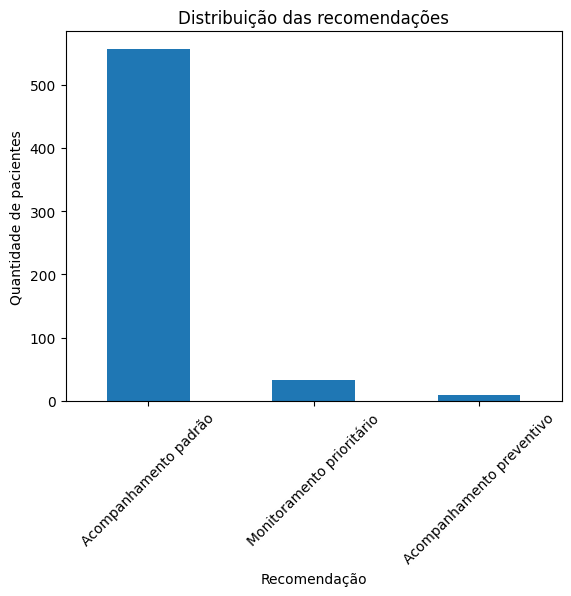

In [32]:
df_prescritivo["Recomendacao"].value_counts().plot(kind="bar")

plt.title("Distribuição das recomendações")
plt.xlabel("Recomendação")
plt.ylabel("Quantidade de pacientes")
plt.xticks(rotation=45)
plt.show()


## 19. Prescrição com restrição operacional

Na vida real, recursos são limitados.

Exemplo:

> A equipe só consegue acompanhar prioritariamente 30 pacientes.

Vamos selecionar os 30 pacientes com maior probabilidade prevista de internação.


In [33]:
capacidade_prioritaria = 30

pacientes_prioritarios = df_prescritivo.sort_values(
    by="Probabilidade_Internacao",
    ascending=False
).head(capacidade_prioritaria)

pacientes_prioritarios[[
    "Paciente_ID",
    "Idade",
    "Exposicao",
    "Vacinado",
    "Comorbidade",
    "Dias_Sintomas",
    "Marcador_Inflamatorio",
    "Probabilidade_Internacao",
    "Recomendacao"
]]


,Paciente_ID,Idade,Exposicao,Vacinado,Comorbidade,Dias_Sintomas,Marcador_Inflamatorio,Probabilidade_Internacao,Recomendacao
52,53,18,Não exposto,Sim,Não,12,3.77,1.00,Monitoramento prioritário
441,442,59,Não exposto,Sim,Sim,19,8.51,1.00,Monitoramento prioritário
428,429,81,Exposto,Sim,Sim,17,4.36,1.00,Monitoramento prioritário
28,29,42,Não exposto,Sim,Não,10,4.87,1.00,Monitoramento prioritário
319,320,33,Não exposto,Sim,Sim,16,3.57,1.00,Monitoramento prioritário
573,574,57,Exposto,Sim,Sim,19,5.44,1.00,Monitoramento prioritário
126,127,49,Exposto,Não,Sim,19,4.49,1.00,Monitoramento prioritário
372,373,39,Não exposto,Não,Não,12,4.62,1.00,Monitoramento prioritário
142,143,35,Não exposto,Sim,Sim,17,4.12,1.00,Monitoramento prioritário
229,230,43,Exposto,Sim,Sim,15,4.11,1.00,Monitoramento prioritário


### Interpretação

Esse é um exemplo simples de prescrição com restrição:

- Objetivo: priorizar pacientes com maior risco previsto;
- Restrição: apenas 30 vagas de acompanhamento prioritário;
- Ação: ordenar por risco e selecionar os primeiros.


## 20. Simulação de cenário: efeito da vacinação

Vamos simular:

> O que aconteceria com a probabilidade prevista se todos constassem como vacinados?

Atenção: isso é uma simulação didática, não comprovação causal.


In [34]:
df_cenario_vacinacao = X.copy()

df_cenario_vacinacao["Vacinado"] = "Sim"

proba_cenario = modelo.predict_proba(df_cenario_vacinacao)[:, indice_sim]

comparacao_cenario = pd.DataFrame({
    "Probabilidade_Original": df_prescritivo["Probabilidade_Internacao"],
    "Probabilidade_Cenario_Vacinado": proba_cenario
})

comparacao_cenario["Diferenca"] = (
    comparacao_cenario["Probabilidade_Cenario_Vacinado"]
    - comparacao_cenario["Probabilidade_Original"]
)

comparacao_cenario.head()


,Probabilidade_Original,Probabilidade_Cenario_Vacinado,Diferenca
0,0.00,0.00,0.00
1,0.03,0.03,0.00
2,0.00,0.00,0.00
3,0.03,0.03,0.00
4,0.00,0.00,0.00


In [35]:
comparacao_cenario[[
    "Probabilidade_Original",
    "Probabilidade_Cenario_Vacinado",
    "Diferenca"
]].mean()


Probabilidade_Original           0.08
Probabilidade_Cenario_Vacinado   0.09
Diferenca                        0.01
dtype: float64

## 21. Simulação de cenário: redução do marcador inflamatório

Agora vamos simular uma redução de 20% no marcador inflamatório.


In [36]:
df_cenario_marcador = X.copy()

df_cenario_marcador["Marcador_Inflamatorio"] = (
    df_cenario_marcador["Marcador_Inflamatorio"] * 0.80
)

proba_marcador = modelo.predict_proba(df_cenario_marcador)[:, indice_sim]

comparacao_marcador = pd.DataFrame({
    "Probabilidade_Original": df_prescritivo["Probabilidade_Internacao"],
    "Probabilidade_Cenario_Marcador_-20%": proba_marcador
})

comparacao_marcador["Diferenca"] = (
    comparacao_marcador["Probabilidade_Cenario_Marcador_-20%"]
    - comparacao_marcador["Probabilidade_Original"]
)

comparacao_marcador[[
    "Probabilidade_Original",
    "Probabilidade_Cenario_Marcador_-20%",
    "Diferenca"
]].mean()


Probabilidade_Original                 0.08
Probabilidade_Cenario_Marcador_-20%    0.06
Diferenca                             -0.02
dtype: float64

## 22. Comparação visual dos cenários

Vamos comparar a probabilidade média original com os cenários simulados.


In [37]:
media_original = df_prescritivo["Probabilidade_Internacao"].mean()
media_vacinacao = proba_cenario.mean()
media_marcador = proba_marcador.mean()

cenarios = pd.DataFrame({
    "Cenario": [
        "Original",
        "Todos vacinados",
        "Marcador -20%"
    ],
    "Probabilidade_Media_Internacao": [
        media_original,
        media_vacinacao,
        media_marcador
    ]
})

cenarios


,Cenario,Probabilidade_Media_Internacao
0,Original,0.08
1,Todos vacinados,0.09
2,Marcador -20%,0.06


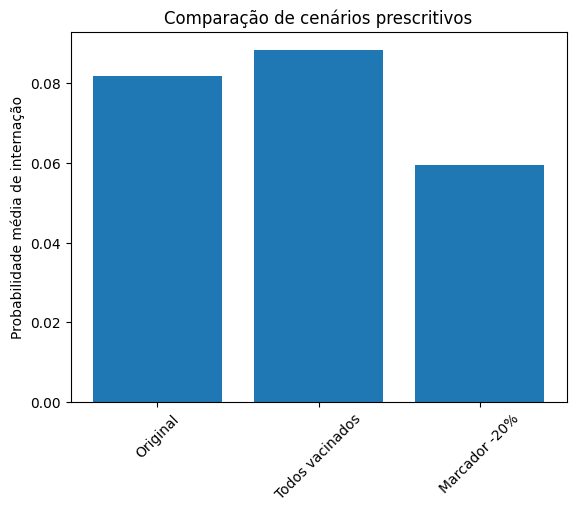

In [38]:
plt.bar(cenarios["Cenario"], cenarios["Probabilidade_Media_Internacao"])

plt.title("Comparação de cenários prescritivos")
plt.ylabel("Probabilidade média de internação")
plt.xticks(rotation=45)
plt.show()


## 23. Transformando análise em recomendação

Com base nas análises, poderíamos propor recomendações como:

- priorizar acompanhamento de pacientes com maior risco previsto;
- monitorar pacientes com comorbidade e marcador inflamatório elevado;
- incentivar ações preventivas em grupos com maior risco;
- revisar periodicamente o modelo com novos dados;
- avaliar se as recomendações estão produzindo resultados melhores.

Essas recomendações representam a passagem da análise preditiva para a análise prescritiva.


# Conclusão Final

## Análise Preditiva

Respondemos:

> **O que provavelmente pode acontecer?**

Nesta aula, treinamos um modelo para prever internação com base em variáveis do paciente.

Aprendemos a:

- separar treino e teste;
- treinar um modelo de árvore de decisão;
- avaliar previsões;
- interpretar matriz de confusão;
- observar importância das variáveis;
- prever novos pacientes.

## Análise Prescritiva

Respondemos:

> **O que deve ser feito?**

A partir das probabilidades previstas, criamos recomendações como:

- acompanhamento padrão;
- acompanhamento preventivo;
- monitoramento prioritário.

Também simulamos cenários e aplicamos restrição operacional.

## Insight final

> A predição estima risco.  
> A prescrição transforma risco em ação.

Em saúde, qualquer recomendação real exigiria validação técnica, ética, clínica e institucional.
